### Import Important Libraries.

In [5]:
# Libraries for Exploretion
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Remove unwanted warnings
import warnings
warnings.filterwarnings('ignore')

# Machine learnig libraries 
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder
from sklearn.utils.class_weight import compute_class_weight

# Deep leaning libraries
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, LSTM, GRU, Dropout

# NLP libraries 
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import string
import html
from bs4 import BeautifulSoup

# Utility
import pickle
import time
import joblib
import gc
# Display the versions of some important libraries
print(f'Version of Pandas {pd.__version__}')
print(f'Version of TensorFlow {tf.__version__}')

Version of Pandas 2.2.3
Version of TensorFlow 2.20.0


### Let's Load the Dataset


In [6]:
# Link of our Dataset
train_path='train.csv'
#Load the data into DataFrame
print("📥 Loading training dataset...")
df=pd.read_csv(train_path,header=None,names=("polarity","title","text"))
print("\n" + "="*60)
print("DATASET LOADING COMPLETE")
print("="*60)

#Display first few rows
print("\n🔍 First 5 rows of training data:")
df.head()

📥 Loading training dataset...

DATASET LOADING COMPLETE

🔍 First 5 rows of training data:


,polarity,title,text
0,2,Stuning even for the non-gamer,This sound track was beautiful! It paints the ...
1,2,The best soundtrack ever to anything.,I'm reading a lot of reviews saying that this ...
2,2,Amazing!,This soundtrack is my favorite music of all ti...
3,2,Excellent Soundtrack,I truly like this soundtrack and I enjoy video...
4,2,"Remember, Pull Your Jaw Off The Floor After He...","If you've played the game, you know how divine..."


### Explore the data

In [7]:
#Shape of the dataset
print(f'\n 📊 Shape of the dataset is {df.shape}')
print(f'\n Number of Rows is {df.shape[0]} & Number of columns is {df.shape[1]}')


 📊 Shape of the dataset is (3600000, 3)

 Number of Rows is 3600000 & Number of columns is 3


In [8]:
#Let's verify the data structure and contents
print("🔎 DATA STRUCTURE ANALYSIS")
print("="*50)

#check column information
print("\n📋 Training Data Info:")
df.info()


🔎 DATA STRUCTURE ANALYSIS

📋 Training Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3600000 entries, 0 to 3599999
Data columns (total 3 columns):
 #   Column    Dtype 
---  ------    ----- 
 0   polarity  int64 
 1   title     object
 2   text      object
dtypes: int64(1), object(2)
memory usage: 82.4+ MB


In [9]:
# check the unique values of polarity
print('\n No of Unique values in polarity column')
print("-"*30)
print(df['polarity'].nunique())
print('\n Check the Skewness of the polarity column')
print("-"*30)
df['polarity'].value_counts()


 No of Unique values in polarity column
------------------------------
2

 Check the Skewness of the polarity column
------------------------------


polarity
2    1800000
1    1800000
Name: count, dtype: int64

In [10]:
#Check for any null values
print("\n❓ MISSING VALUES ANALYSIS:")
print("-" * 30)
print("Training Data:")
print(df.isnull().sum())


❓ MISSING VALUES ANALYSIS:
------------------------------
Training Data:
polarity      0
title       207
text          0
dtype: int64


In [11]:
#Check datatypes
print("\n📝 DATA TYPES:")
print("-" * 30)
print(df.dtypes)


📝 DATA TYPES:
------------------------------
polarity     int64
title       object
text        object
dtype: object


### Feature Engineering for Human Understanding

In [12]:
#Feature engineering
polarity_map={1:'Negative',2:'Positive'}
df['sentiment']=df['polarity'].map(polarity_map)

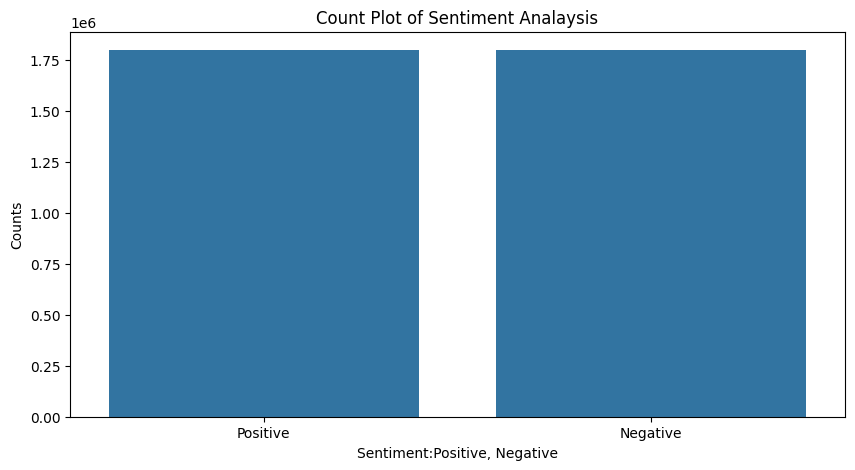

In [13]:
#plot for sentiment analysis
plt.figure(figsize=(10,5))
sns.countplot(data=df,x='sentiment')
plt.title('Count Plot of Sentiment Analaysis')
plt.xlabel('Sentiment:Positive, Negative')
plt.ylabel('Counts')
plt.show()

In [14]:
# how many words in one review and length of review
df['text_length']=df['text'].astype(str).apply(len)
df['word_count']=df['text'].astype(str).apply(lambda x:len(x.split()))
print("\n📏 TEXT LENGTH STATISTICS:")
print(f"\nTraining Data:")
print(f"  Average characters per review: {df['text_length'].mean():.0f}")
print(f" Maximum text length in a review: {df['text_length'].max()}")
print(f"  Average words per review: {df['word_count'].mean():.0f}")
print(f"  Maximum words in a review: {df['word_count'].max():,}")
print(f"  Minimum words in a review: {df['word_count'].min()}")


📏 TEXT LENGTH STATISTICS:

Training Data:
  Average characters per review: 405
 Maximum text length in a review: 1010
  Average words per review: 74
  Maximum words in a review: 254
  Minimum words in a review: 1


In [15]:
# Check the 1 word rows
df[df['word_count']==1].head()

,polarity,title,text,sentiment,text_length,word_count
567147,2,Great,TeTerriffic!Terriffic!Terriffic!Terriffic!Terr...,Positive,122,1
589388,1,The War on Christmas: How the Liberal Plot to ...,drek,Negative,4,1
629878,1,"You can get all of theese songs off of ""Dial A...",...............................,Negative,31,1
759194,1,Disappointing,Thisis.the.very.first.book.by.her.that.I.had.a...,Negative,180,1
817508,1,dags go bam here,gogogogagagagagagamandiffheuejkuawieuajdsifjhj...,Negative,100,1


In [16]:
df=df.drop(df[df['word_count']==1].index)

In [17]:
df[df['word_count']==2].head()

,polarity,title,text,sentiment,text_length,word_count
866882,2,Lost,threewolveseverhowlingmoonabovemocksme?birdin ...,Positive,122,2
937431,2,//:practical//logikal//clear explanations//cra...,//:practical//logikal//clear explanations//cra...,Positive,53,2
1716559,2,How to Care for and Preserve Your Collectibles...,Awesome achievement!,Positive,20,2
2217671,1,Be Afraid. Be Very...,Upset.Annoyed.Confused.Pissed.Suckered.OUT.OF....,Negative,205,2
2461384,2,yueyhhryeujfgjthjkaghlkqkyl[efbldsf;kh[keyg[ok...,"hytrwhgfdgdfvgbcxbdgs,b'lf,g;lrektg;ldfag;lfxk...",Positive,171,2


In [18]:
df=df.drop(df[df['word_count']==2].index)

In [19]:
df[df['word_count']==3].head()

,polarity,title,text,sentiment,text_length,word_count
372567,2,Great Purchase,Great Purchase CKVKLJ;JNVKZ;KCVJJVK'ZJXC'VKLZX...,Positive,90,3
1553176,2,Thoughts & Feelings: Taking Control of Your Mo...,just the job,Positive,12,3
1779039,1,i thought anthony minghella was incapable of m...,"oops, mine bad!",Negative,15,3
2194309,2,Highly recommended for those with a strong int...,Length:: 0:38 Mins,Positive,18,3
2205587,1,Item was chipped/damaged,Item was chipped/damaged.........................,Negative,91,3


In [20]:
df=df.drop(df[df['word_count']==3].index)

In [21]:
# 1. Select only necessary columns and create a copy for preprocessing
print("\n🔧 STEP 1: SELECTING AND PREPARING DATA")
print("-" * 40)
preprocessed_df=df.sample(frac=0.5,random_state=42)
preprocessed_df=preprocessed_df[['text','sentiment']].copy()
print(preprocessed_df.isnull().sum())
print(f'Duplicated values in the dataset: {preprocessed_df.duplicated().sum()}')

print(f"Training data shape before preprocessing: {preprocessed_df.shape}")
# Check current sentiment distribution
print("\n📊 Current Sentiment Distribution:")
print(preprocessed_df['sentiment'].value_counts())


🔧 STEP 1: SELECTING AND PREPARING DATA
----------------------------------------
text         0
sentiment    0
dtype: int64
Duplicated values in the dataset: 1464
Training data shape before preprocessing: (1799983, 2)

📊 Current Sentiment Distribution:
sentiment
Negative    900401
Positive    899582
Name: count, dtype: int64


In [22]:
#Drop duplicate rows from the Dataframe
preprocessed_df=preprocessed_df.drop_duplicates()

In [23]:
#2. convert sentiment to binary(0=Negative,1=Postivie)
print("\n🔧 STEP 2: CONVERTING SENTIMENT TO BINARY")
print("-" * 40)
preprocessed_df['sentiment'] = preprocessed_df['sentiment'].map({'Negative': 0, 'Positive': 1})

print("\n✅ Binary Sentiment Distribution:")
print("Training:")

preprocessed_df['sentiment'].value_counts()


🔧 STEP 2: CONVERTING SENTIMENT TO BINARY
----------------------------------------

✅ Binary Sentiment Distribution:
Training:


sentiment
0    899325
1    899194
Name: count, dtype: int64

In [24]:
# 3. Comprehensive Text Cleaning Function
print("\n🔧 STEP 3: TEXT CLEANING FUNCTION")
print("-" * 40)

def clean_text(text):
    """
    Comprehensive text cleaning function
    """
    if not isinstance(text,str):
        return ""

    # 1. Decode HTML entities
    text=html.unescape(text)

     # 2. Remove HTML tags using BeautifulSoup
    text=BeautifulSoup(text,"html.parser").get_text()
    
     # 3. Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # 4. Remove email addresses
    text = re.sub(r'\S*@\S*\s?', '', text)
    
    # 5. Remove special characters and numbers (keep only letters and basic punctuation)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # 6. Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    # 7. Convert to lowercase
    text = text.lower()
    
    # 8. Remove punctuation (optional - can be done during tokenization)
    # text = text.translate(str.maketrans('', '', string.punctuation))
    
    return text

# Test the cleaning function
print("🧪 Testing cleaning function on sample text:")
sample_text = "This is a <b>test `~\<>@#$%^&()_-+=|\[{}]; ,   : </b> review with http://example.com link and   email@test.com!!! #awesome"
print(f"Original: {sample_text}")
print(f"Cleaned: {clean_text(sample_text)}")
    
    



🔧 STEP 3: TEXT CLEANING FUNCTION
----------------------------------------
🧪 Testing cleaning function on sample text:
Original: This is a <b>test `~\<>@#$%^&()_-+=|\[{}]; ,   : </b> review with http://example.com link and   email@test.com!!! #awesome
Cleaned: this is a test review with link and awesome


In [25]:
# Function to clean text
def clean_texts(text):
    text = re.sub(r'<.*?>', '', text)  # Remove HTML tags
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # Remove non-alphabet characters
    return text.lower().strip()


# Test the cleaning function
print("🧪 Testing cleaning function on sample text:")
sample_text = "This is a <b>test `~\<>@#$%^&()_-+=|\[{}]; .,   : </b> review with http://example.com link and   email@test.com!!! #awesome"
print(f"Original: {sample_text}")
print(f"Cleaned: {clean_texts(sample_text)}")

🧪 Testing cleaning function on sample text:
Original: This is a <b>test `~\<>@#$%^&()_-+=|\[{}]; .,   : </b> review with http://example.com link and   email@test.com!!! #awesome
Cleaned: this is a test       review with httpexamplecom link and   emailtestcom awesome


In [26]:
preprocessed_df.head()

,text,sentiment
306104,"Honestly, I would think real hard before I buy...",0
3369546,THIS IS A WONDERFULLY WRITTEN HISTORICAL FICTI...,1
2688290,There's no question that Mary Fahl has a great...,0
2730642,this is the best dvd that i have ever seen i h...,1
1870506,"Well, I don't know if it's the world's best cu...",1


In [27]:
#Clean the text
preprocessed_df['text']=preprocessed_df['text'].apply(clean_text)

In [28]:
#Tokenization and padding
tokenizer=Tokenizer(num_words=50000,oov_token='<00V>')
tokenizer.fit_on_texts(preprocessed_df['text'])
sequences=tokenizer.texts_to_sequences(preprocessed_df['text'])
padded_sequences=pad_sequences(sequences,maxlen=200)

In [29]:
X=padded_sequences
y=preprocessed_df['sentiment'].values

In [30]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

### Building the Neural Netwok with TensorFlow

In [31]:
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(50000, 16, input_length=200),  # Embedding layer
    tf.keras.layers.LSTM(64, return_sequences=True),          # First LSTM layer with return sequences
    tf.keras.layers.LSTM(32),                                  # Second LSTM layer
    tf.keras.layers.Dense(24, activation='relu'),             # Dense layer
    tf.keras.layers.Dense(1, activation='sigmoid')            # Output layer
])

model.compile(
    loss='binary_crossentropy',                                # Loss function for binary classification
    optimizer='adam',                                         # Optimizer
    metrics=['accuracy']                                      # Metric to evaluate performance
)

model.summary()  # Should show the model parameters

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [32]:
history=model.fit(X_train,y_train,epochs=10,validation_split=0.2)

Epoch 1/10
35971/35971 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - accuracy: 0.8773 - loss: 0.2878

KeyboardInterrupt: 

### Visualizing Model Performance

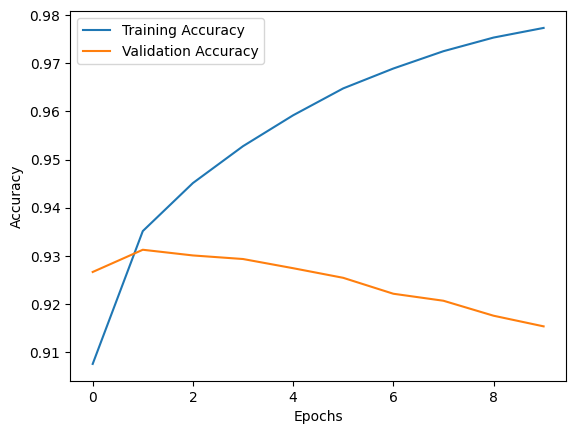

In [ ]:
plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

### Evaluating the Model

In [ ]:
test_loss,test_accuracy=model.evaluate(X_test,y_test)
print(f'Test Accuracy: {test_accuracy:.2f}')

11241/11241 ━━━━━━━━━━━━━━━━━━━━ 73s 7ms/step - accuracy: 0.9151 - loss: 0.2820
Test Accuracy: 0.92


### Making Predicitons

In [ ]:
sample_reviews = [
    "I absolutely loved this product! solve many problems use in daily life.",
    "It is bad item on amazon. it's priced very high but quality is very low."
]

sample_sequences = tokenizer.texts_to_sequences(sample_reviews)
sample_padded = pad_sequences(sample_sequences, maxlen=200)

predictions = model.predict(sample_padded)
print(["Positive" if prob > 0.5 else "Negative" for prob in predictions])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
['Positive', 'Negative']


In [ ]:
# Save the model to the output directory
model.save('sentiment_model.h5')

# Save the tokenizer as well
import pickle
with open('tokenizer.pickle', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

In [ ]:
!pip install pipreqsnb

In [ ]:
!pipreqsnb --savepath ./requirements.txt /kaggle/working/__notebook__.ipynb